# Urban Connectivity and Business Success Analysis
## Analyzing the relationship between urban mobility scores and Yelp business metrics

This notebook analyzes how urban connectivity (Walk Score, Transit Score, Bike Score) relates to business success metrics (ratings, review counts) across different business categories.

In [216]:
# Setup and Imports
import pandas as pd
import numpy as np
import kagglehub
import os
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import tukey_hsd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from mpl_toolkits.mplot3d import Axes3D

pd.options.display.max_rows = 100
plt.style.use('seaborn-v0_8-whitegrid')

In [217]:
# Load datasets
try:
    urban_path = kagglehub.dataset_download("vellis1/us-cities-urban-connectivity")
    yelp_path = kagglehub.dataset_download("yelp-dataset/yelp-dataset")
except Exception as e:
    raise RuntimeError(f"Failed to download datasets from Kaggle: {e}")

# Load urban connectivity data
files = os.listdir(urban_path)
csv_files = [f for f in files if f.endswith('.csv')]
if not csv_files:
    raise FileNotFoundError(f"No CSV file found in {urban_path}")
urban_df = pd.read_csv(os.path.join(urban_path, csv_files[0]))

# Load Yelp business data
yelp_business_path = os.path.join(yelp_path, "yelp_academic_dataset_business.json")
if not os.path.exists(yelp_business_path):
    raise FileNotFoundError(f"Yelp business dataset not found at {yelp_business_path}")
yelp_df = pd.read_json(yelp_business_path, lines=True)

print(f"Urban data shape: {urban_df.shape}")
print(f"Yelp data shape: {yelp_df.shape}")

Urban data shape: (102, 79)
Yelp data shape: (150346, 14)


In [218]:
# Category mapping rules - comprehensive keyword matching
MAJOR_RULES = {
    "Food & Dining": [
        "restaurant","food","cafe","coffee","tea","bar","bakery","dessert","ice cream",
        "pizza","burger","sandwich","noodle","ramen","sushi","mexican","italian","korean",
        "thai","indian","chinese","japanese","mediterranean","halal","vegan","vegetarian",
        "brunch","breakfast","deli","seafood","steakhouse","bbq","brew","wine","pub",
        "grocery","market","butcher","donut","bagel","taco","poke","buffet","food truck",
        "american (traditional)","american (new)","salad","chicken wings","cajun","creole",
        "southern","diners","latin american","soup","vietnamese","asian fusion",
        "middle eastern","gluten-free","tex-mex","greek","french","cuban","fish & chips",
        "dim sum","creperies","hawaiian","falafel","african","puerto rican","turkish",
        "german","cantonese","hot pot","filipino","brazilian","ethiopian","kosher",
        "pakistani","irish","szechuan","lebanese","kebab","brasseries","pan asian",
        "empanadas","persian","iranian","teppanyaki","malaysian","fondue","izakaya",
        "shanghainese","mongolian","himalayan","nepalese","ukrainian","egyptian",
        "singaporean","burmese","armenian","syrian","scandinavian","australian",
        "bangladeshi","sicilian","senegalese","haitian","trinidadian","iberian",
        "hungarian","somali","sardinian","georgian","sri lankan","guamanian",
        "serbo croatian","czech","hainan","israeli","fuzhou","south african",
        "colombian","peruvian","venezuelan","salvadoran","dominican","russian",
        "honduran","laotian","argentine","belgian","portuguese","british","moroccan",
        "afghan","arabic","polish","cambodian","indonesian","basque","taiwanese",
        "smokehouse","pretzels","waffles","shaved ice","acai bowls","gelato",
        "custom cakes","cupcakes","fruits & veggies","wraps","kombucha",
        "herbs & spices","olive oil","honey","pancakes","beer hall","poutineries",
        "bistros","street vendors","personal chefs","distilleries","cideries",
        "meaderies","speakeasies","beer","cucina campana","tuscan","austrian", "bakeries"
    ],
    "Shopping & Retail": [
        "store","shop","shopping","fashion","clothing","jewelry","gift","book","electronics",
        "furniture","thrift","antique","cosmetic","supply","wholesale","mall","marketplace",
        "shoe","accessories","toy","department","boutique",
        "home decor","sporting goods","mags","used","vintage & consignment",
        "mobile phones","building supplies","kitchen & bath","eyewear & opticians",
        "mattresses","watches","lighting fixtures","outdoor gear","guns & ammo",
        "leather goods","vinyl records","lingerie","costumes","formal wear",
        "motorcycle gear","hats","perfume","luggage","swimwear","knitting supplies",
        "customized merchandise","wigs","religious items","uniforms","kitchen supplies",
        "office equipment","rugs","shades & blinds","tableware","military surplus",
        "hunting & fishing supplies","gemstones & minerals","gold buyers",
        "diamond buyers","firewood","safety equipment","vitamins & supplements",
        "computers","signmaking","framing","grilling equipment"
    ],
    "Beauty & Personal Care": [
        "salon","spa","hair","nail","wax","tattoo","piercing","massage","skin","makeup",
        "barber","tanning","eyelash","threading","facial",
        "blow dry/out services","eyebrow services","sugaring","acne treatment",
        "aestheticians","estheticians"
    ],
    "Health & Medical": [
        "doctor","dentist","hospital","medical","clinic","therapy","chiropractor",
        "optometrist","psychologist","psychiatrist","surgeon","pharmacy","rehab",
        "urgent care","health","wellness","nutrition",
        "orthodontists","endodontists","periodontists","family practice",
        "acupuncture","reflexology","weight loss centers","diagnostic services",
        "dermatologists","ophthalmologists","internal medicine","obstetricians",
        "gynecologists","pediatricians","orthopedists","naturopathic","holistic",
        "reiki","laboratory testing","pain management","laser eye surgery","lasik",
        "allergists","gastroenterologist","neurologist","podiatrists","ear nose & throat",
        "radiologists","urologists","fertility","endocrinologists","oncologist",
        "sleep specialists","osteopathic physicians","audiologist","prosthodontists",
        "nurse practitioner","addiction medicine","dental hygienists","dietitians",
        "hearing aid providers","pulmonologist","speech therapists","vascular medicine",
        "emergency rooms","emergency medicine","iv hydration","colonics",
        "alternative medicine","meditation centers","tui na","tai chi","qi gong",
        "ayurveda","preventive medicine","concierge medicine","lactation services",
        "midwives","hospice","skilled nursing","assisted living facilities",
        "diagnostic imaging","teeth whitening","orthotics"
    ],
    "Automotive": [
        "auto","car","vehicle","tire","oil change","repair","dealer","towing","smog",
        "body shop","transmission","glass","detailing",
        "gas stations","roadside assistance","ev charging stations"
    ],
    "Home & Local Services": [
        "plumbing","electrician","hvac","roof","contractor","cleaning","locksmith",
        "moving","landscaping","flooring","installation","repair","maintenance","handyman",
        "appliance","home service","garden",
        "local services","movers","sewing & alterations","printing services",
        "shipping centers","pest control","painters","tree services",
        "junk removal & hauling","damage restoration","masonry/concrete",
        "packing services","pool & hot tub service","irrigation","window washing",
        "landscape architects","pool cleaners","gutter services","pressure washers",
        "garage door services","fences & gates","home window tinting","cabinetry",
        "tiling","laundry services","laundromat","refinishing services",
        "grout services","demolition services","stucco services","snow removal",
        "siding","decks & railing","chimney sweeps","fireplace services",
        "hydro-jetting","septic services","tv mounting","shutters","patio coverings",
        "home inspectors","home organization","home staging","awnings",
        "fire protection services","environmental abatement","screen printing",
        "interior design","florists","floral designers","swimming pools",
        "hot tub & pool","home energy auditors","well drilling","excavation services",
        "backflow services","wallpapering","powder coating","grill services",
        "wildlife control","home developers","interlock systems",
        "sheds & outdoor storage","security systems","security services",
        "environmental testing"
    ],
    "Real Estate & Housing": [
        "real estate","apartment","property","mortgage","housing","leasing",
        "condominiums","self storage","homeowner association"
    ],
    "Professional & Financial Services": [
        "law","legal","account","insurance","tax","consult","financial","bank",
        "notary","payday","broker","business service",
        "professional services","general litigation","investing",
        "check cashing/pay-day loans","title loans","installment loans",
        "debt relief services","payroll services","employment agencies",
        "advertising","graphic design","web design","appraisal services",
        "registration services","personal assistants","wills","trusts","& probates",
        "business financing","process servers","editorial services",
        "translation services","software development","billing services",
        "data recovery","internet service providers","utilities",
        "electricity suppliers","talent agencies","structural engineers"
    ],
    "Entertainment & Recreation": [
        "gym","fitness","park","museum","art","music","theater","cinema","club",
        "karaoke","festival","sports","golf","yoga","dance","arcade","game",
        "recreation","bowling","casino",
        "nightlife","active life","event planning & services","lounges",
        "trainers","boot camps","pilates","jazz & blues","kids activities",
        "pool halls","boxing","stadiums & arenas","skating rinks","hiking",
        "boating","kickboxing","tennis","mountain biking","climbing",
        "brazilian jiu-jitsu","horseback riding","fishing","gun/rifle ranges",
        "rafting/kayaking","axe throwing","paint & sip","challenge courses",
        "diving","scuba diving","rock climbing","laser tag","paintball",
        "virtual reality centers","archery","skydiving","surfing","tubing",
        "hot air balloons","batting cages","sailing","free diving",
        "adult entertainment","adult","haunted houses","scavenger hunts",
        "jet skis","soccer","basketball courts","baseball fields","marinas",
        "opera & ballet","playgrounds","summer camps","day camps",
        "indoor playcentre","aquariums","zoos","landmarks & historical buildings",
        "local flavor","libraries","beaches","lakes","campgrounds",
        "horse racing","race tracks","djs","pool & billiards","eatertainment",
        "pumpkin patches","attraction farms","bike sharing","bicycle paths",
        "pickleball","bocce ball","badminton","skiing","sledding",
        "outdoor movies","bingo halls","rodeo","airsoft","cannabis dispensaries",
        "cannabis collective","bikes","swimming pools","snowboarding",
        "hang gliding","ziplining","snorkeling","trivia hosts",
        "recording & rehearsal studios","video/film production","magicians",
        "face painting","clowns","wildlife hunting ranges","metal detector services"
    ],
    "Education": [
        "school","college","university","tutor","training","education","class","lesson",
        "test preparation"
    ],
    "Travel & Transportation": [
        "hotel","travel","tour","airport","taxi","transport","rental","shuttle",
        "airline","resort","vacation",
        "limos","guest houses","hostels","train stations","buses","bus stations",
        "ferries","pedicabs","valet services","luggage storage","rest stops",
        "visitor centers","trains","flight instruction"
    ],
    "Pets": [
        "pet","veterinarian","animal","dog","cat","groomer","boarding",
        "aquarium services"
    ],
    "Community & Public Services": [
        "community service/non-profit","religious organizations","churches",
        "cultural center","community centers","funeral services & cemeteries",
        "cremation services","mortuary services","post offices","courthouses",
        "donation center","recycling center","blood & plasma donation centers",
        "synagogues","buddhist temples","hindu temples","mosques",
        "homeless shelters","jails & prisons","municipality","embassy",
        "crisis pregnancy centers","faith-based crisis pregnancy centers",
        "adoption services","hospice"
    ],
    "Events & Weddings": [
        "wedding planning","bridal","photographers","session photography",
        "event photography","boudoir photography","videographers",
        "wedding chapels","officiants","balloon services","holiday decorations",
        "holiday decorating services","christmas trees","paint-your-own pottery",
        "screen printing/t-shirt printing","engraving","calligraphy",
        "digitizing services","customized merchandise"
    ]
}

def map_major_category(category):
    if pd.isna(category):
        return "Other"
    c = category.lower()
    for major, keywords in MAJOR_RULES.items():
        for k in keywords:
            if k in c:
                return major
    return "Other"

In [219]:
# Data Cleaning and Merging
urban_df = urban_df.rename(columns={"State": "state", "City": "city"})

# Merge on both city and state for accurate geographic matching
combined = pd.merge(left=urban_df, right=yelp_df, 
                    left_on=["city", "state"], 
                    right_on=["city", "state"], 
                    how="inner")

# Process categories
combined['categories'] = combined['categories'].str.split(", ")
combined = combined.explode('categories')
combined["major_category"] = combined["categories"].apply(map_major_category)

# Create Travel Score (composite mobility metric)
combined['Travel_Score'] = (combined['Walk Score'] + combined['Transit Score'] + combined['Bike Score']) / 3

# Filter to open businesses only
combined = combined[combined['is_open'] == 1]

# Keep relevant columns
keep_cols = ['Place_name', 'city', 'state', 'Walk Score', 'Transit Score', 'Bike Score',
             'business_id', 'name', 'postal_code', 'latitude', 'longitude', 
             'stars', 'review_count', 'major_category', 'Travel_Score']
combined = combined[[col for col in keep_cols if col in combined.columns]]

# Deduplicate by business_id for business-level analysis
combined_deduped = combined.drop_duplicates(subset=['business_id'])

print(f"Combined dataset shape: {combined.shape}")
print(f"Unique businesses: {combined_deduped.shape[0]}")
print(f"Unique cities: {combined_deduped['city'].nunique()}")

Combined dataset shape: (191058, 15)
Unique businesses: 42074
Unique cities: 14


In [220]:
# Create multi-hot encoded dataset for multivariate analysis
combined_onehot = pd.get_dummies(combined[['business_id', 'major_category']], 
                                  columns=['major_category'], dtype=int)

# Group by business_id to create multi-hot encoding
category_cols = [col for col in combined_onehot.columns if col.startswith('major_category_')]
business_categories = combined_onehot.groupby('business_id')[category_cols].max().reset_index()

# Merge back with business data
combined_final = combined_deduped.drop(columns=['major_category']).merge(business_categories, on='business_id')
combined_final = combined_final.dropna()

print(f"Final dataset shape: {combined_final.shape}")

Final dataset shape: (42074, 29)


---
# 1. Inferential Statistics

This section conducts hypothesis tests to investigate significant differences and correlations within the data, including:
- **ANOVA**: Testing if Travel Score differs across business categories
- **Chi-Square Test**: Testing if business type distribution differs by transit accessibility
- **Regression Analysis**: Testing if mobility scores predict business engagement

## 1.1 One-Way ANOVA: Travel Score Across Business Categories

**Research Question:** Does the average Travel Score differ significantly across business categories?

**Hypotheses:**
- H0 (Null): All business category means for Travel Score are equal
- H1 (Alternative): At least one category mean differs from the others

**Significance Level:** alpha = 0.05

**Test Justification:** ANOVA is appropriate because we are comparing means across more than two independent groups (business categories) with a continuous dependent variable (Travel Score).

In [221]:
# Prepare data for ANOVA
category_groups = [group['Travel_Score'].values 
                   for name, group in combined.groupby('major_category')]
category_names = list(combined.groupby('major_category').groups.keys())

# Descriptive statistics by category
travel_by_category = combined.groupby('major_category')['Travel_Score'].agg(['mean', 'std', 'count'])
travel_by_category = travel_by_category.sort_values('mean', ascending=False)
print("Descriptive Statistics: Travel Score by Business Category")
print(travel_by_category.round(2))

Descriptive Statistics: Travel Score by Business Category
                                    mean    std  count
major_category                                        
Food & Dining                      51.10  14.34  63015
Community & Public Services        50.76  13.37    782
Education                          50.01  13.57   2011
Other                              49.95  13.46   1234
Entertainment & Recreation         49.93  13.93  21640
Beauty & Personal Care             49.88  13.61  15030
Professional & Financial Services  49.53  13.21   4292
Events & Weddings                  49.46  14.38    943
Shopping & Retail                  49.37  13.54  24093
Pets                               49.34  13.40   4312
Home & Local Services              49.31  13.12  19736
Real Estate & Housing              48.90  13.65   3954
Health & Medical                   48.90  12.82  12956
Travel & Transportation            48.53  13.34   5295
Automotive                         48.37  12.68  11765


In [222]:
# One-Way ANOVA
f_stat, anova_p = stats.f_oneway(*category_groups)

print("="*60)
print("ONE-WAY ANOVA RESULTS")
print("="*60)
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {anova_p:.2e}")
print(f"\nSignificance level: alpha = 0.05")
print(f"\nConclusion: {'REJECT H0' if anova_p < 0.05 else 'FAIL TO REJECT H0'}")
if anova_p < 0.05:
    print("There is a statistically significant difference in Travel Score across business categories.")

ONE-WAY ANOVA RESULTS
F-statistic: 61.5279
P-value: 2.06e-174

Significance level: alpha = 0.05

Conclusion: REJECT H0
There is a statistically significant difference in Travel Score across business categories.


In [223]:
# Kruskal-Wallis Test (non-parametric alternative for robustness check)
h_stat, kw_p = stats.kruskal(*category_groups)

print("="*60)
print("KRUSKAL-WALLIS TEST (Non-parametric validation)")
print("="*60)
print(f"H-statistic: {h_stat:.4f}")
print(f"P-value: {kw_p:.2e}")
print(f"\nConclusion: {'REJECT H0' if kw_p < 0.05 else 'FAIL TO REJECT H0'}")

KRUSKAL-WALLIS TEST (Non-parametric validation)
H-statistic: 975.9154
P-value: 2.30e-199

Conclusion: REJECT H0


In [224]:
# Effect Size: Eta-squared
grand_mean = combined['Travel_Score'].mean()
ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in category_groups)
ss_total = sum((combined['Travel_Score'] - grand_mean)**2)
eta_squared = ss_between / ss_total

print("="*60)
print("EFFECT SIZE")
print("="*60)
print(f"Eta-squared: {eta_squared:.4f}")
print(f"Interpretation: {eta_squared*100:.2f}% of variance in Travel Score is explained by business category")
print(f"\nEffect size guidelines: Small < 0.01, Medium ~ 0.06, Large > 0.14")
effect_size = "small" if eta_squared < 0.06 else ("medium" if eta_squared < 0.14 else "large")
print(f"This is a {effect_size} effect size.")

EFFECT SIZE
Eta-squared: 0.0045
Interpretation: 0.45% of variance in Travel Score is explained by business category

Effect size guidelines: Small < 0.01, Medium ~ 0.06, Large > 0.14
This is a small effect size.


In [225]:
# Post-hoc: Tukey's HSD for pairwise comparisons
tukey_result = tukey_hsd(*category_groups)

# Extract significant pairwise differences
significant_pairs = []
for i in range(len(category_names)):
    for j in range(i+1, len(category_names)):
        p_val = tukey_result.pvalue[i, j]
        if p_val < 0.05:
            mean_i = travel_by_category.loc[category_names[i], 'mean']
            mean_j = travel_by_category.loc[category_names[j], 'mean']
            significant_pairs.append({
                'Category 1': category_names[i],
                'Category 2': category_names[j],
                'Mean Difference': mean_i - mean_j,
                'P-value': p_val
            })

sig_df = pd.DataFrame(significant_pairs).sort_values('P-value')
print("="*60)
print(f"POST-HOC ANALYSIS: Tukey's HSD")
print(f"Significant pairwise differences (p < 0.05): {len(sig_df)} pairs")
print("="*60)
print(sig_df.head(15).to_string(index=False))

POST-HOC ANALYSIS: Tukey's HSD
Significant pairwise differences (p < 0.05): 38 pairs
                Category 1                        Category 2  Mean Difference      P-value
Entertainment & Recreation                     Food & Dining        -1.169045 0.000000e+00
                Automotive        Entertainment & Recreation        -1.565861 0.000000e+00
                Automotive                     Food & Dining        -2.734906 0.000000e+00
             Food & Dining                  Health & Medical         2.205120 0.000000e+00
             Food & Dining           Travel & Transportation         2.569665 0.000000e+00
             Food & Dining                 Shopping & Retail         1.731984 0.000000e+00
             Food & Dining             Home & Local Services         1.797467 0.000000e+00
    Beauty & Personal Care                     Food & Dining        -1.222192 0.000000e+00
             Food & Dining             Real Estate & Housing         2.199744 0.000000e+00
     

## 1.2 Chi-Square Test: Business Type Distribution by Transit Accessibility

**Research Question:** Is the distribution of business types different between high and low Travel Score areas?

**Hypotheses:**
- H0 (Null): Business type distribution is independent of Travel Score level
- H1 (Alternative): Business type distribution depends on Travel Score level

**Significance Level:** alpha = 0.05

**Test Justification:** Chi-square test of independence is appropriate because we are testing the relationship between two categorical variables.

In [226]:
# Reset index to avoid duplicate label issues from explode operation
combined = combined.reset_index(drop=True)

# Create high/low travel score groups based on median
median_travel = combined['Travel_Score'].median()
combined['travel_group'] = combined['Travel_Score'].apply(
    lambda x: 'High Transit' if x >= median_travel else 'Low Transit'
)

# Create contingency table
contingency = pd.crosstab(combined['major_category'], combined['travel_group'])

print("Contingency Table: Business Counts by Category and Travel Score Group")
print(contingency)

Contingency Table: Business Counts by Category and Travel Score Group
travel_group                       High Transit  Low Transit
major_category                                              
Automotive                                 6169         5596
Beauty & Personal Care                     7927         7103
Community & Public Services                 478          304
Education                                  1124          887
Entertainment & Recreation                12232         9408
Events & Weddings                           484          459
Food & Dining                             36805        26210
Health & Medical                           6612         6344
Home & Local Services                     10913         8823
Other                                       685          549
Pets                                       2390         1922
Professional & Financial Services          2191         2101
Real Estate & Housing                      1979         1975
Shopping & Reta

In [227]:
# Chi-Square Test
chi2, chi2_p, dof, expected = stats.chi2_contingency(contingency)

print("="*60)
print("CHI-SQUARE TEST OF INDEPENDENCE")
print("="*60)
print(f"Chi-square statistic: {chi2:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"P-value: {chi2_p:.2e}")
print(f"\nSignificance level: alpha = 0.05")
print(f"\nConclusion: {'REJECT H0' if chi2_p < 0.05 else 'FAIL TO REJECT H0'}")
if chi2_p < 0.05:
    print("Business type distribution is significantly different between high and low transit areas.")

# Effect size: Cramer's V
n = contingency.sum().sum()
min_dim = min(contingency.shape) - 1
cramers_v = np.sqrt(chi2 / (n * min_dim))
print(f"\nEffect Size (Cramer's V): {cramers_v:.4f}")
print(f"Interpretation: {'Small' if cramers_v < 0.1 else ('Medium' if cramers_v < 0.3 else 'Large')} effect")

CHI-SQUARE TEST OF INDEPENDENCE
Chi-square statistic: 526.0055
Degrees of freedom: 14
P-value: 2.83e-103

Significance level: alpha = 0.05

Conclusion: REJECT H0
Business type distribution is significantly different between high and low transit areas.

Effect Size (Cramer's V): 0.0525
Interpretation: Small effect


## 1.3 Regression Analysis: Mobility Scores Predicting Business Engagement

**Research Question:** Do Walk Score, Transit Score, and Bike Score predict business engagement (review count)?

**Hypotheses:**
- H0 (Null): Mobility scores do not predict review count (all coefficients = 0)
- H1 (Alternative): At least one mobility score predicts review count

**Significance Level:** alpha = 0.05

**Test Justification:** Multiple linear regression is appropriate for multiple continuous predictors and a continuous outcome.

In [228]:
# Prepare data for regression (log-transform review count due to skew)
combined_final['log_review_count'] = np.log1p(combined_final['review_count'])

X = combined_final[['Walk Score', 'Transit Score', 'Bike Score']]
y = combined_final['log_review_count']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit model
model = LinearRegression()
model.fit(X_train, y_train)

# Results
print("="*60)
print("MULTIPLE LINEAR REGRESSION RESULTS")
print("Dependent Variable: Log(Review Count)")
print("="*60)
print(f"\nCoefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"  {feature}: {coef:.6f}")
print(f"  Intercept: {model.intercept_:.6f}")

train_r2 = model.score(X_train, y_train)
test_r2 = model.score(X_test, y_test)
print(f"\nModel Fit:")
print(f"  R-squared (Training): {train_r2:.4f}")
print(f"  R-squared (Test): {test_r2:.4f}")

MULTIPLE LINEAR REGRESSION RESULTS
Dependent Variable: Log(Review Count)

Coefficients:
  Walk Score: 0.005723
  Transit Score: -0.000004
  Bike Score: -0.005279
  Intercept: 3.203796

Model Fit:
  R-squared (Training): 0.0027
  R-squared (Test): 0.0035


---
# 2. Graphical Analysis

This section creates various visualizations to explore patterns, trends, and outliers in the data.

## 2.1 Histograms: Distribution of Key Variables

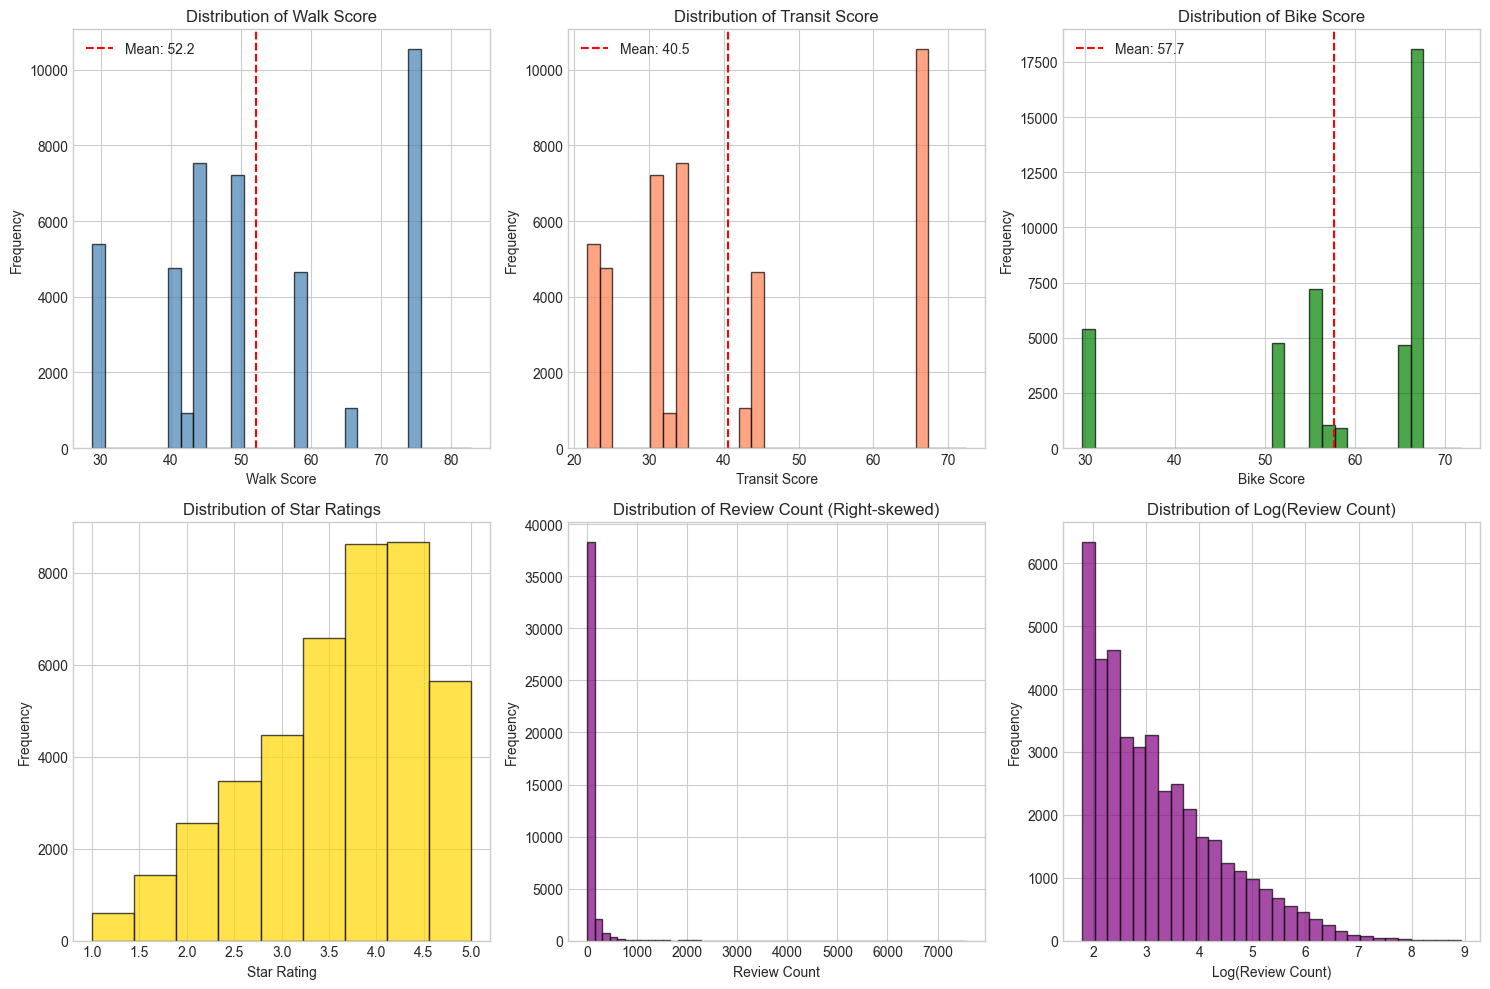


Observations:
- Review count is heavily right-skewed, requiring log transformation
- Star ratings are left-skewed with most businesses rated 3.5-4.5 stars


In [229]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Walk Score
axes[0, 0].hist(combined_final['Walk Score'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].set_xlabel('Walk Score')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Walk Score')
axes[0, 0].axvline(combined_final['Walk Score'].mean(), color='red', linestyle='--', label=f'Mean: {combined_final["Walk Score"].mean():.1f}')
axes[0, 0].legend()

# Transit Score
axes[0, 1].hist(combined_final['Transit Score'], bins=30, edgecolor='black', alpha=0.7, color='coral')
axes[0, 1].set_xlabel('Transit Score')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of Transit Score')
axes[0, 1].axvline(combined_final['Transit Score'].mean(), color='red', linestyle='--', label=f'Mean: {combined_final["Transit Score"].mean():.1f}')
axes[0, 1].legend()

# Bike Score
axes[0, 2].hist(combined_final['Bike Score'], bins=30, edgecolor='black', alpha=0.7, color='green')
axes[0, 2].set_xlabel('Bike Score')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].set_title('Distribution of Bike Score')
axes[0, 2].axvline(combined_final['Bike Score'].mean(), color='red', linestyle='--', label=f'Mean: {combined_final["Bike Score"].mean():.1f}')
axes[0, 2].legend()

# Star Rating
axes[1, 0].hist(combined_final['stars'], bins=9, edgecolor='black', alpha=0.7, color='gold')
axes[1, 0].set_xlabel('Star Rating')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Star Ratings')

# Review Count (original - showing skew)
axes[1, 1].hist(combined_final['review_count'], bins=50, edgecolor='black', alpha=0.7, color='purple')
axes[1, 1].set_xlabel('Review Count')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Distribution of Review Count (Right-skewed)')

# Review Count (log-transformed)
axes[1, 2].hist(combined_final['log_review_count'], bins=30, edgecolor='black', alpha=0.7, color='purple')
axes[1, 2].set_xlabel('Log(Review Count)')
axes[1, 2].set_ylabel('Frequency')
axes[1, 2].set_title('Distribution of Log(Review Count)')

plt.tight_layout()
plt.show()

print("\nObservations:")
print("- Review count is heavily right-skewed, requiring log transformation")
print("- Star ratings are left-skewed with most businesses rated 3.5-4.5 stars")

## 2.2 Bar Charts

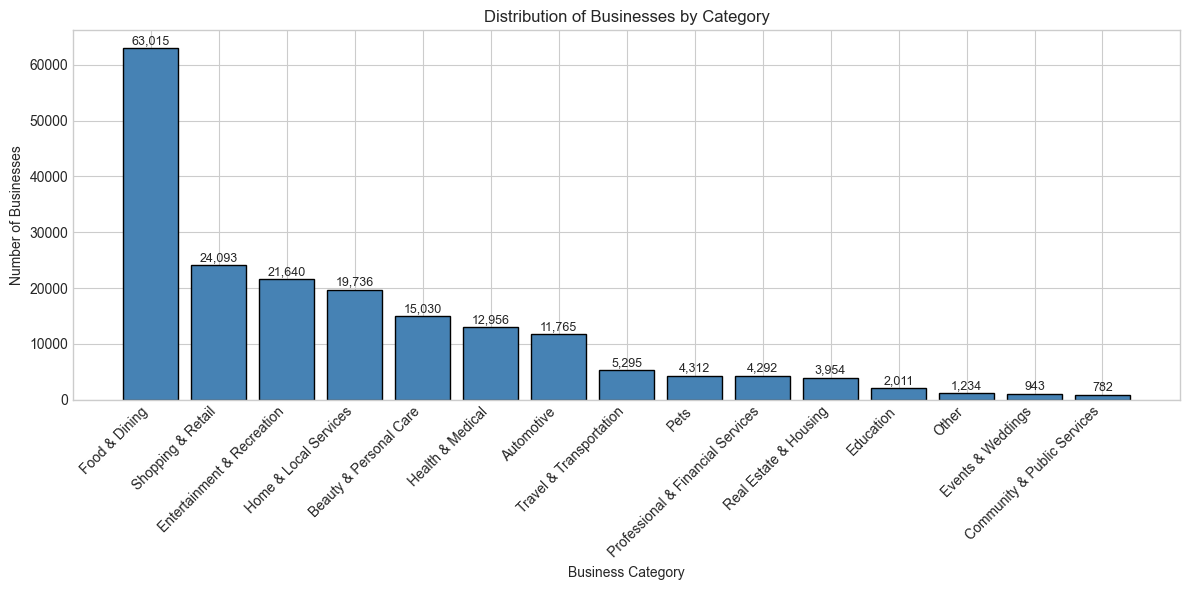

In [230]:
# Business count by category
category_counts = combined['major_category'].value_counts()

plt.figure(figsize=(12, 6))
bars = plt.bar(range(len(category_counts)), category_counts.values, color='steelblue', edgecolor='black')
plt.xticks(range(len(category_counts)), category_counts.index, rotation=45, ha='right')
plt.xlabel('Business Category')
plt.ylabel('Number of Businesses')
plt.title('Distribution of Businesses by Category')
for bar, val in zip(bars, category_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200, f'{val:,}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

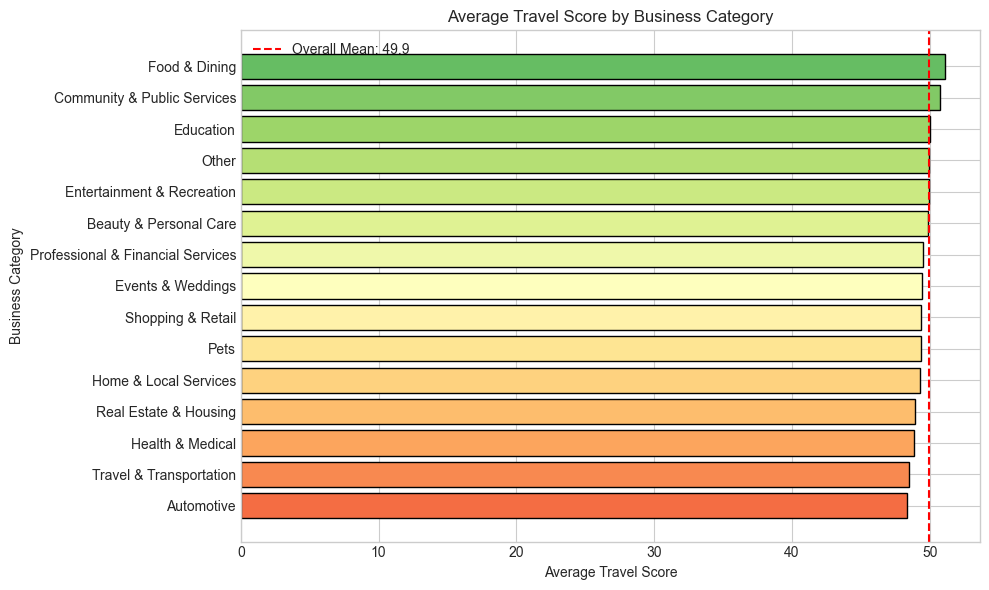

In [231]:
# Average Travel Score by category
travel_means = combined.groupby('major_category')['Travel_Score'].mean().sort_values(ascending=True)

plt.figure(figsize=(10, 6))
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(travel_means)))
plt.barh(travel_means.index, travel_means.values, color=colors, edgecolor='black')
plt.xlabel('Average Travel Score')
plt.ylabel('Business Category')
plt.title('Average Travel Score by Business Category')
plt.axvline(combined['Travel_Score'].mean(), color='red', linestyle='--', label=f'Overall Mean: {combined["Travel_Score"].mean():.1f}')
plt.legend()
plt.tight_layout()
plt.show()

## 2.3 Box Plots

/var/folders/l_/50s_462d2p18z6_x65mc6x5r0000gn/T/ipykernel_48839/612154221.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=combined, x='major_category', y='Travel_Score', order=category_order, palette='viridis')


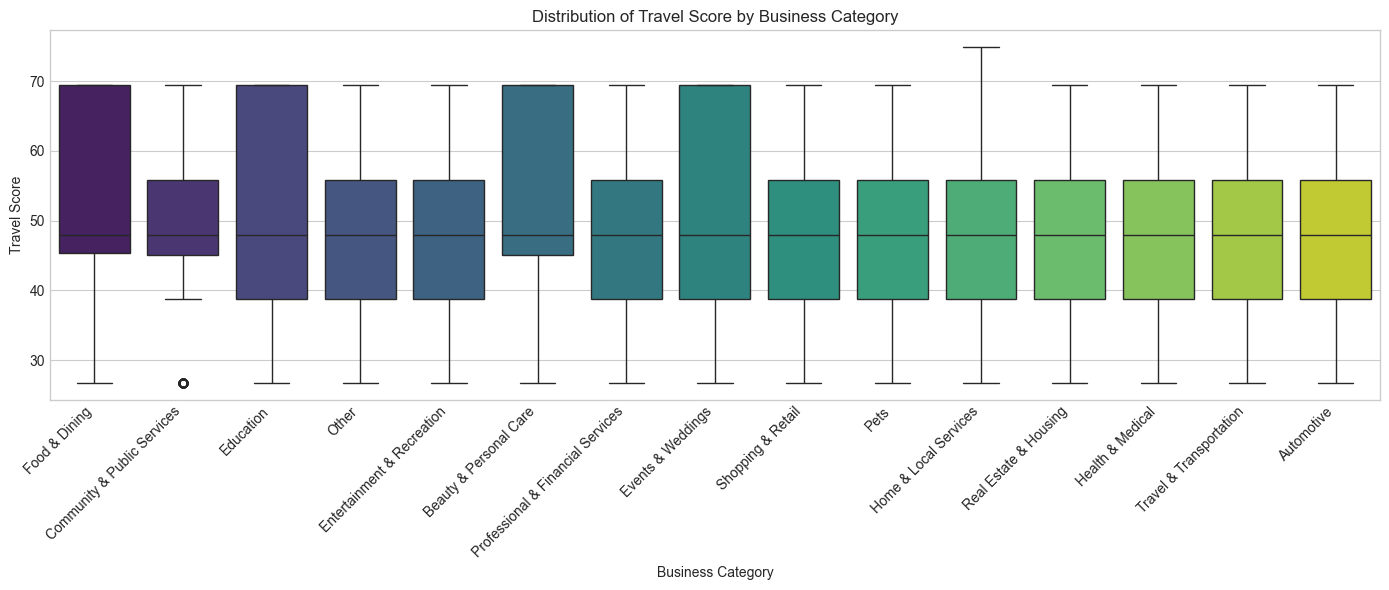


Interpretation:
- Food & Dining businesses tend to be in higher-transit areas
- Automotive businesses tend to be in lower-transit areas


In [232]:
# Box plot: Travel Score by Business Category
plt.figure(figsize=(14, 6))
category_order = travel_means.index.tolist()[::-1]
sns.boxplot(data=combined, x='major_category', y='Travel_Score', order=category_order, palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Business Category')
plt.ylabel('Travel Score')
plt.title('Distribution of Travel Score by Business Category')
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("- Food & Dining businesses tend to be in higher-transit areas")
print("- Automotive businesses tend to be in lower-transit areas")

/var/folders/l_/50s_462d2p18z6_x65mc6x5r0000gn/T/ipykernel_48839/1675708649.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=combined_final, x='city', y='stars', order=city_order, palette='Set2')


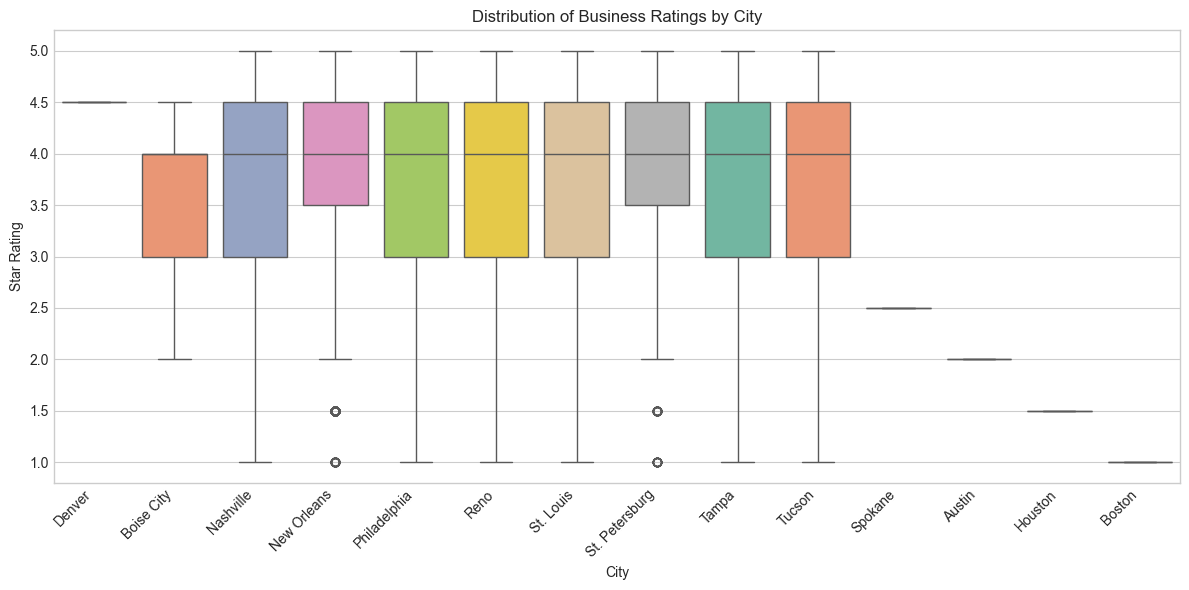

In [233]:
# Box plot: Star Ratings by City
plt.figure(figsize=(12, 6))
city_order = combined_final.groupby('city')['stars'].median().sort_values(ascending=False).index
sns.boxplot(data=combined_final, x='city', y='stars', order=city_order, palette='Set2')
plt.xticks(rotation=45, ha='right')
plt.xlabel('City')
plt.ylabel('Star Rating')
plt.title('Distribution of Business Ratings by City')
plt.tight_layout()
plt.show()

## 2.4 Scatter Plots

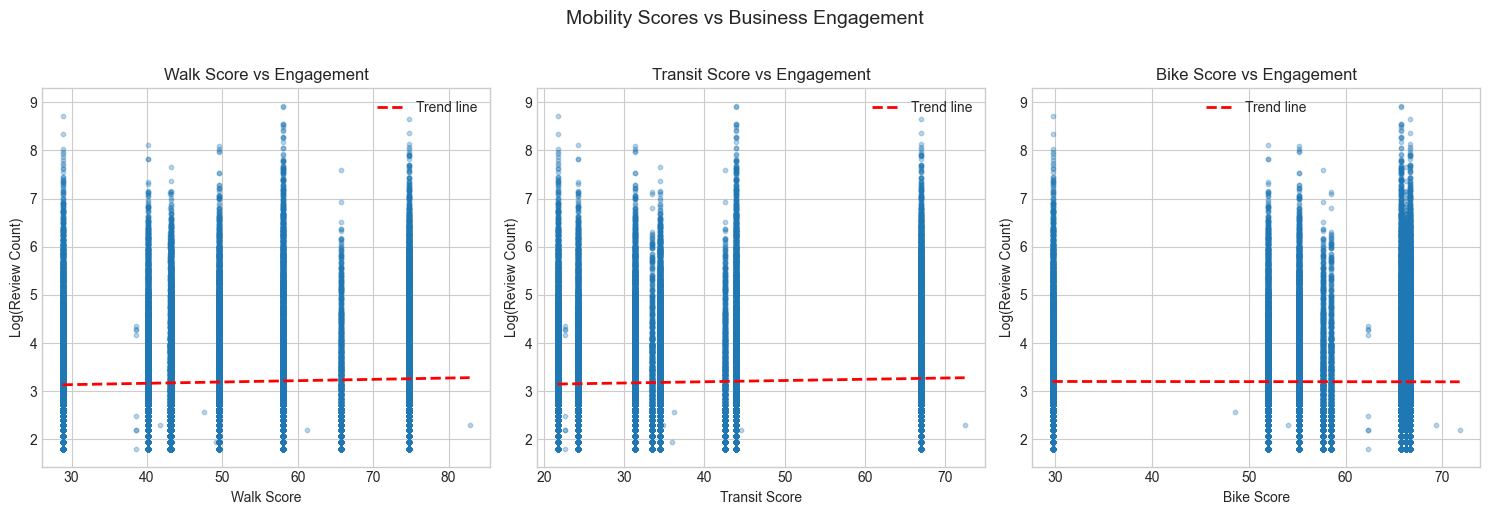

In [234]:
# Scatter plots: Mobility scores vs engagement
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, score in enumerate(['Walk Score', 'Transit Score', 'Bike Score']):
    axes[idx].scatter(combined_final[score], combined_final['log_review_count'], alpha=0.3, s=10)
    z = np.polyfit(combined_final[score], combined_final['log_review_count'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(combined_final[score].min(), combined_final[score].max(), 100)
    axes[idx].plot(x_line, p(x_line), 'r--', linewidth=2, label='Trend line')
    axes[idx].set_xlabel(score)
    axes[idx].set_ylabel('Log(Review Count)')
    axes[idx].set_title(f'{score} vs Engagement')
    axes[idx].legend()

plt.suptitle('Mobility Scores vs Business Engagement', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

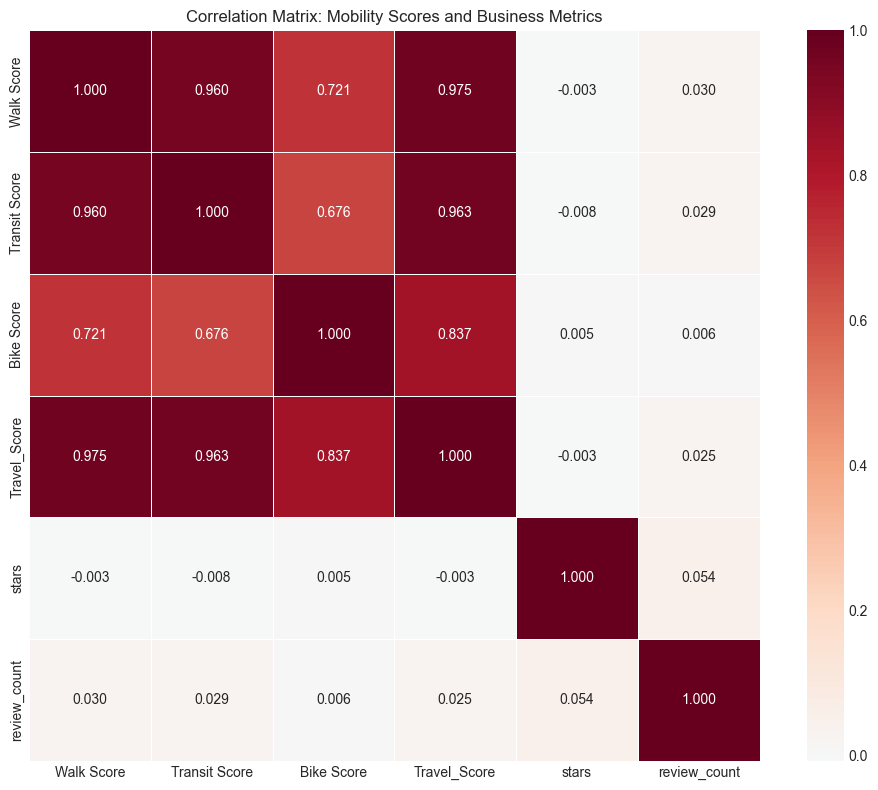

In [235]:
# Correlation heatmap
numeric_cols = ['Walk Score', 'Transit Score', 'Bike Score', 'Travel_Score', 'stars', 'review_count']
corr_matrix = combined_final[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, square=True, linewidths=0.5, fmt='.3f')
plt.title('Correlation Matrix: Mobility Scores and Business Metrics')
plt.tight_layout()
plt.show()

---
# 3. Comparative Analysis

This section compares different subsets of the data across cities and business categories.

## 3.1 City-Level Comparisons

In [236]:
# City-level statistics
city_stats = combined_final.groupby('city').agg({
    'business_id': 'count',
    'stars': 'mean',
    'review_count': 'mean',
    'Walk Score': 'first',
    'Transit Score': 'first',
    'Bike Score': 'first',
    'Travel_Score': 'first'
}).rename(columns={'business_id': 'num_businesses'})
city_stats = city_stats.sort_values('Travel_Score', ascending=False)

print("City-Level Comparison:")
print(city_stats.round(2))

City-Level Comparison:
                num_businesses  stars  review_count  Walk Score  \
city                                                              
Boston                       1   1.00          9.00        82.8   
Philadelphia             10540   3.65         68.34        74.8   
Denver                       1   4.50          8.00        61.2   
New Orleans               4648   3.85        112.96        58.0   
St. Louis                 1053   3.66         50.60        65.7   
Tucson                    7533   3.62         43.33        43.2   
Spokane                      1   2.50          6.00        49.2   
Tampa                     7217   3.60         50.87        49.5   
St. Petersburg             916   3.88         47.52        43.0   
Houston                      1   1.50         12.00        47.5   
Austin                       1   2.00          9.00        41.7   
Boise City                   8   3.56         39.50        38.5   
Reno                      4759   3.79  

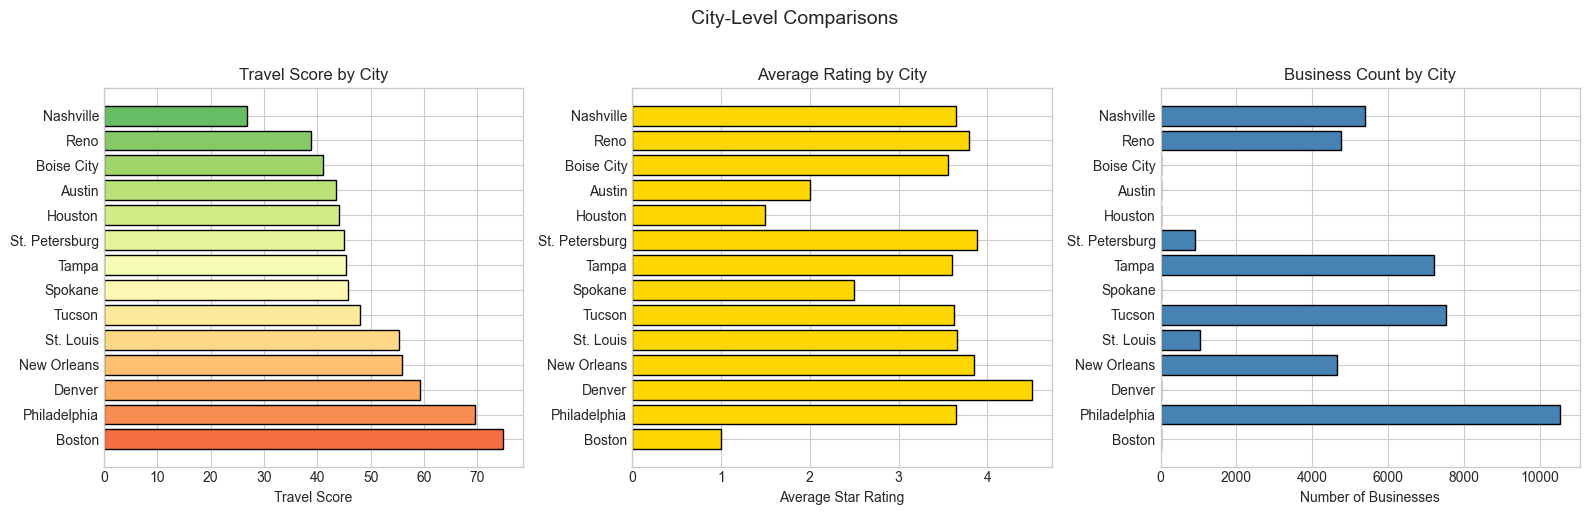

In [237]:
# City comparison visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

cities_sorted = city_stats.index.tolist()
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(cities_sorted)))

axes[0].barh(cities_sorted, city_stats['Travel_Score'], color=colors, edgecolor='black')
axes[0].set_xlabel('Travel Score')
axes[0].set_title('Travel Score by City')

axes[1].barh(cities_sorted, city_stats['stars'], color='gold', edgecolor='black')
axes[1].set_xlabel('Average Star Rating')
axes[1].set_title('Average Rating by City')

axes[2].barh(cities_sorted, city_stats['num_businesses'], color='steelblue', edgecolor='black')
axes[2].set_xlabel('Number of Businesses')
axes[2].set_title('Business Count by City')

plt.suptitle('City-Level Comparisons', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [238]:
# High-transit vs low-transit cities comparison
median_city_travel = city_stats['Travel_Score'].median()
high_transit_cities = city_stats[city_stats['Travel_Score'] >= median_city_travel].index.tolist()
low_transit_cities = city_stats[city_stats['Travel_Score'] < median_city_travel].index.tolist()

high_transit_data = combined_final[combined_final['city'].isin(high_transit_cities)]
low_transit_data = combined_final[combined_final['city'].isin(low_transit_cities)]

print("Comparison: High-Transit vs Low-Transit Cities")
print("="*60)
print(f"High-transit cities: {', '.join(high_transit_cities)}")
print(f"Low-transit cities: {', '.join(low_transit_cities)}")
print(f"\n{'Metric':<25} {'High-Transit':>15} {'Low-Transit':>15}")
print("-"*60)
print(f"{'Number of businesses':<25} {len(high_transit_data):>15,} {len(low_transit_data):>15,}")
print(f"{'Average rating':<25} {high_transit_data['stars'].mean():>15.2f} {low_transit_data['stars'].mean():>15.2f}")
print(f"{'Average review count':<25} {high_transit_data['review_count'].mean():>15.1f} {low_transit_data['review_count'].mean():>15.1f}")

Comparison: High-Transit vs Low-Transit Cities
High-transit cities: Boston, Philadelphia, Denver, New Orleans, St. Louis, Tucson, Spokane
Low-transit cities: Tampa, St. Petersburg, Houston, Austin, Boise City, Reno, Nashville

Metric                       High-Transit     Low-Transit
------------------------------------------------------------
Number of businesses               23,777          18,297
Average rating                       3.68            3.68
Average review count                 68.3            58.0


## 3.2 Business Category Comparisons

In [239]:
# Category statistics
category_stats = combined.groupby('major_category').agg({
    'business_id': 'nunique',
    'stars': 'mean',
    'review_count': 'mean',
    'Travel_Score': 'mean'
}).rename(columns={'business_id': 'num_businesses'})
category_stats = category_stats.sort_values('num_businesses', ascending=False)

print("Business Category Comparison:")
print(category_stats.round(2))

Business Category Comparison:
                                   num_businesses  stars  review_count  \
major_category                                                           
Food & Dining                               17414   3.69        152.61   
Entertainment & Recreation                  10439   4.00         82.27   
Shopping & Retail                            9753   3.72         34.03   
Home & Local Services                        8618   3.64         21.16   
Automotive                                   5269   3.63         30.53   
Beauty & Personal Care                       5235   4.06         45.12   
Health & Medical                             4178   3.68         19.23   
Travel & Transportation                      2429   3.50         75.60   
Pets                                         2082   4.03         45.56   
Professional & Financial Services            2045   3.53         17.18   
Real Estate & Housing                        1817   3.07         17.18   
Other   

<Figure size 1200x600 with 0 Axes>

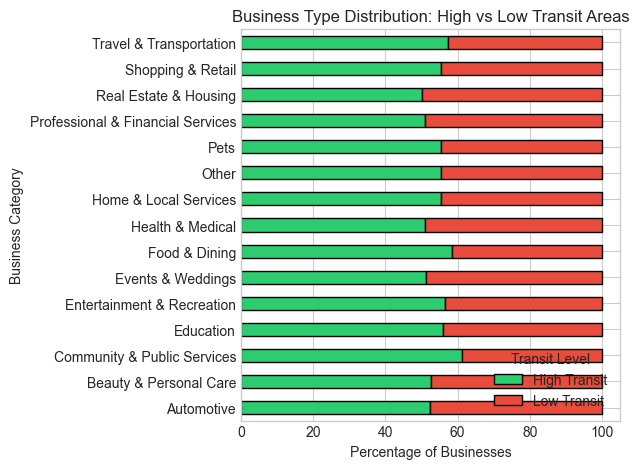


Key Findings:
- Food & Dining has highest proportion in high-transit areas
- Automotive businesses are more common in low-transit areas


In [240]:
# Category distribution by travel group
contingency_pct = contingency.div(contingency.sum(axis=1), axis=0) * 100

plt.figure(figsize=(12, 6))
contingency_pct.plot(kind='barh', stacked=True, color=['#2ecc71', '#e74c3c'], edgecolor='black')
plt.xlabel('Percentage of Businesses')
plt.ylabel('Business Category')
plt.title('Business Type Distribution: High vs Low Transit Areas')
plt.legend(title='Transit Level', loc='lower right')
plt.tight_layout()
plt.show()

print("\nKey Findings:")
print("- Food & Dining has highest proportion in high-transit areas")
print("- Automotive businesses are more common in low-transit areas")

---
# 4. Multivariate Analysis

This section examines relationships among three or more variables using cross-tabulation, pivot tables, and multivariate visualizations.

## 4.1 Cross-Tabulation: Mobility Scores x Category x Engagement

In [241]:
# Create mobility quartiles
combined_final['Walk_Q'] = pd.qcut(combined_final['Walk Score'], q=4, labels=['Low', 'Med-Low', 'Med-High', 'High'])
combined_final['Transit_Q'] = pd.qcut(combined_final['Transit Score'], q=4, labels=['Low', 'Med-Low', 'Med-High', 'High'])
combined_final['Bike_Q'] = pd.qcut(combined_final['Bike Score'], q=4, labels=['Low', 'Med-Low', 'Med-High', 'High'])

# Melt category columns
category_cols = [col for col in combined_final.columns if col.startswith('major_category_')]
multivar_df = combined_final.melt(
    id_vars=['business_id', 'Walk Score', 'Transit Score', 'Bike Score', 
             'Walk_Q', 'Transit_Q', 'Bike_Q', 'review_count', 'stars', 'log_review_count', 'city'],
    value_vars=category_cols,
    var_name='category',
    value_name='belongs'
)
multivar_df = multivar_df[multivar_df['belongs'] == 1].copy()
multivar_df['category'] = multivar_df['category'].str.replace('major_category_', '')

print(f"Multivariate dataset shape: {multivar_df.shape}")

Multivariate dataset shape: (72391, 13)


In [242]:
# Pivot table: Walk Score Quartile x Category x Average Review Count
pivot_walk = multivar_df.pivot_table(values='review_count', index='category', columns='Walk_Q', aggfunc='mean')

print("Cross-Tabulation: Average Review Count")
print("Rows: Business Category | Columns: Walk Score Quartile")
print("="*60)
print(pivot_walk.round(1))

Cross-Tabulation: Average Review Count
Rows: Business Category | Columns: Walk Score Quartile
Walk_Q                               Low  Med-Low  Med-High  High
category                                                         
Automotive                          30.8     27.2      32.8   NaN
Beauty & Personal Care              51.2     42.7      58.3   NaN
Community & Public Services         27.0     23.7      31.4   NaN
Education                           25.1     21.4      26.2   NaN
Entertainment & Recreation          95.6     77.3     110.7   NaN
Events & Weddings                   25.9     26.5      32.3   NaN
Food & Dining                      120.0     90.3     133.1   NaN
Health & Medical                    20.2     17.0      23.0   NaN
Home & Local Services               21.7     18.8      24.5   9.0
Other                               25.4     24.9      45.7   NaN
Pets                                61.4     53.2      71.7   NaN
Professional & Financial Services   18.7     17.

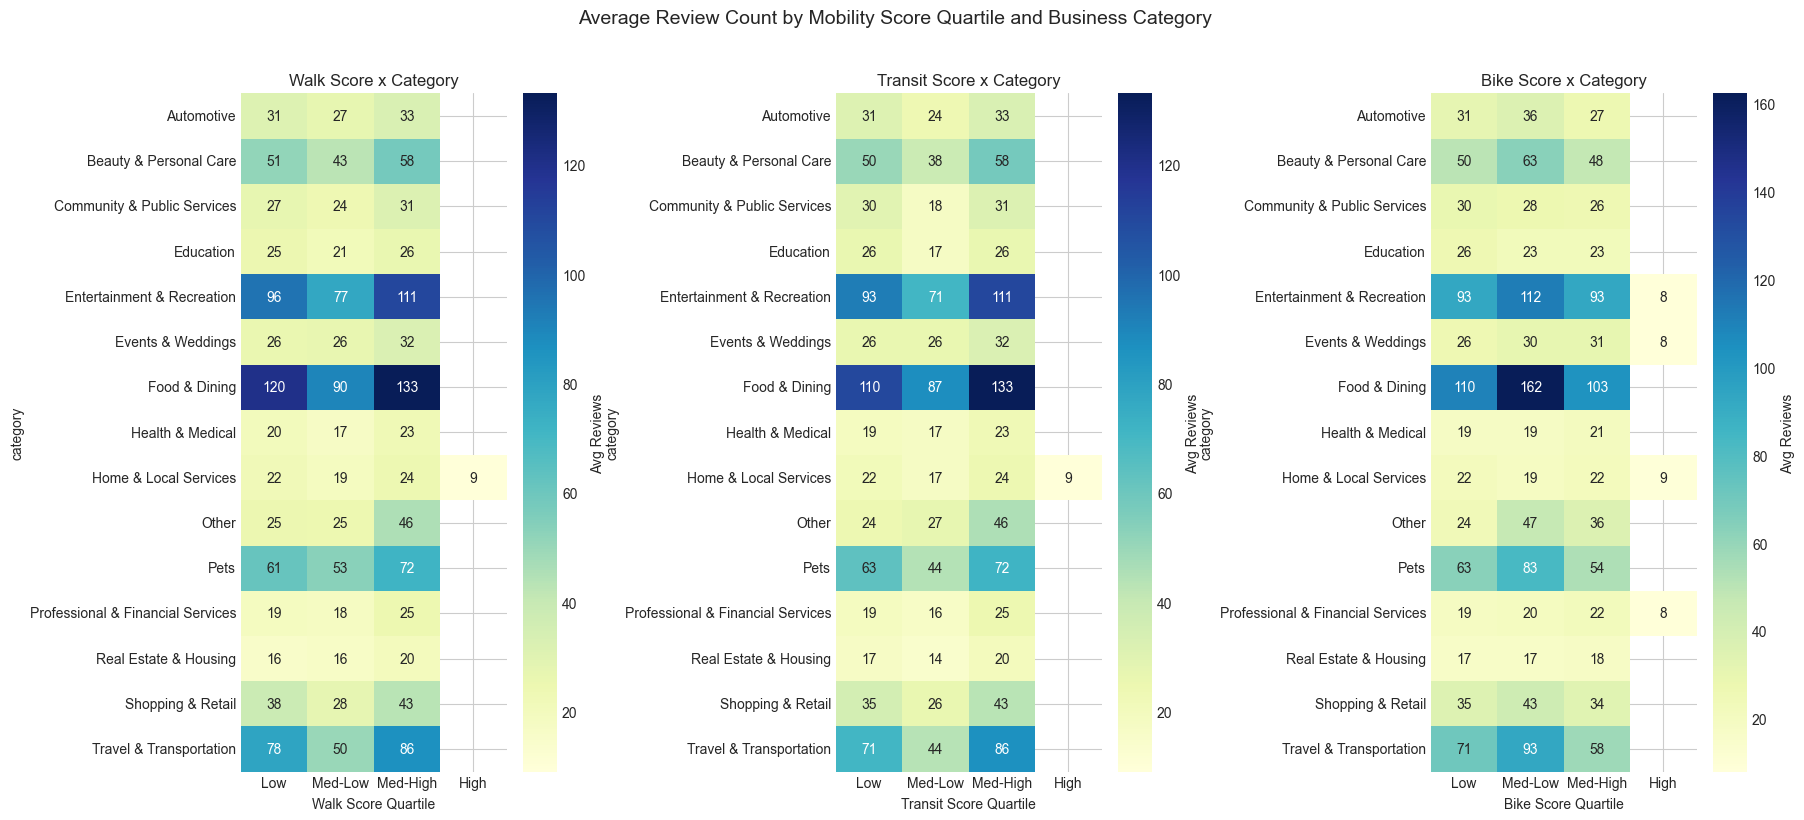

In [243]:
# Heatmaps for all three mobility scores
pivot_transit = multivar_df.pivot_table(values='review_count', index='category', columns='Transit_Q', aggfunc='mean')
pivot_bike = multivar_df.pivot_table(values='review_count', index='category', columns='Bike_Q', aggfunc='mean')

fig, axes = plt.subplots(1, 3, figsize=(18, 8))

sns.heatmap(pivot_walk, annot=True, fmt='.0f', cmap='YlGnBu', ax=axes[0], cbar_kws={'label': 'Avg Reviews'})
axes[0].set_title('Walk Score x Category')
axes[0].set_xlabel('Walk Score Quartile')

sns.heatmap(pivot_transit, annot=True, fmt='.0f', cmap='YlGnBu', ax=axes[1], cbar_kws={'label': 'Avg Reviews'})
axes[1].set_title('Transit Score x Category')
axes[1].set_xlabel('Transit Score Quartile')

sns.heatmap(pivot_bike, annot=True, fmt='.0f', cmap='YlGnBu', ax=axes[2], cbar_kws={'label': 'Avg Reviews'})
axes[2].set_title('Bike Score x Category')
axes[2].set_xlabel('Bike Score Quartile')

plt.suptitle('Average Review Count by Mobility Score Quartile and Business Category', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 4.2 Three-Way Pivot Table

In [244]:
# Three-way pivot: Walk x Transit x Category
top_cats = multivar_df['category'].value_counts().head(6).index.tolist()

three_way_pivot = multivar_df[multivar_df['category'].isin(top_cats)].pivot_table(
    values='review_count',
    index=['Walk_Q', 'Transit_Q'],
    columns='category',
    aggfunc='mean'
)

print("Three-Way Pivot Table: Walk x Transit Quartiles x Category")
print("Values = Average Review Count")
print("="*80)
print(three_way_pivot.round(1))

Three-Way Pivot Table: Walk x Transit Quartiles x Category
Values = Average Review Count
category            Automotive  Beauty & Personal Care  \
Walk_Q   Transit_Q                                       
Low      Low              31.2                    53.0   
         Med-Low          26.1                    35.2   
         Med-High          NaN                     NaN   
Med-Low  Low              31.2                    46.3   
         Med-Low          23.8                    38.7   
         Med-High          NaN                     6.0   
Med-High Med-High         32.8                    58.3   
High     High              NaN                     NaN   

category            Entertainment & Recreation  Food & Dining  \
Walk_Q   Transit_Q                                              
Low      Low                              98.5          123.3   
         Med-Low                          66.8           86.8   
         Med-High                          NaN            NaN   
Med-L

## 4.3 Multivariate Regression by Category

In [245]:
# Multiple regression for each category
regression_results = []

for category in multivar_df['category'].unique():
    cat_data = multivar_df[multivar_df['category'] == category].copy()
    if len(cat_data) < 50:
        continue
    
    X = cat_data[['Walk Score', 'Transit Score', 'Bike Score']]
    y = cat_data['log_review_count']
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    model = LinearRegression()
    model.fit(X_scaled, y)
    
    regression_results.append({
        'Category': category,
        'Walk Score (B)': model.coef_[0],
        'Transit Score (B)': model.coef_[1],
        'Bike Score (B)': model.coef_[2],
        'R-squared': model.score(X_scaled, y),
        'n': len(cat_data)
    })

reg_df = pd.DataFrame(regression_results).sort_values('R-squared', ascending=False)

print("Multivariate Regression: Mobility Scores -> Log(Review Count) by Category")
print("(Standardized coefficients - comparable across predictors)")
print("="*80)
print(reg_df.round(4).to_string(index=False))

Multivariate Regression: Mobility Scores -> Log(Review Count) by Category
(Standardized coefficients - comparable across predictors)
                         Category  Walk Score (B)  Transit Score (B)  Bike Score (B)  R-squared     n
                            Other         -0.0622             0.1722         -0.0329     0.0102   962
      Community & Public Services          0.1833            -0.0753         -0.0953     0.0080   611
                        Education          0.1685            -0.0765         -0.0480     0.0072   951
            Real Estate & Housing          0.0528             0.0114         -0.0095     0.0066  1817
                Events & Weddings         -0.1534             0.1649          0.0541     0.0059   588
Professional & Financial Services          0.0833            -0.0011         -0.0532     0.0054  2045
                 Health & Medical         -0.0829             0.1362         -0.0192     0.0051  4178
                             Pets          0.1514  

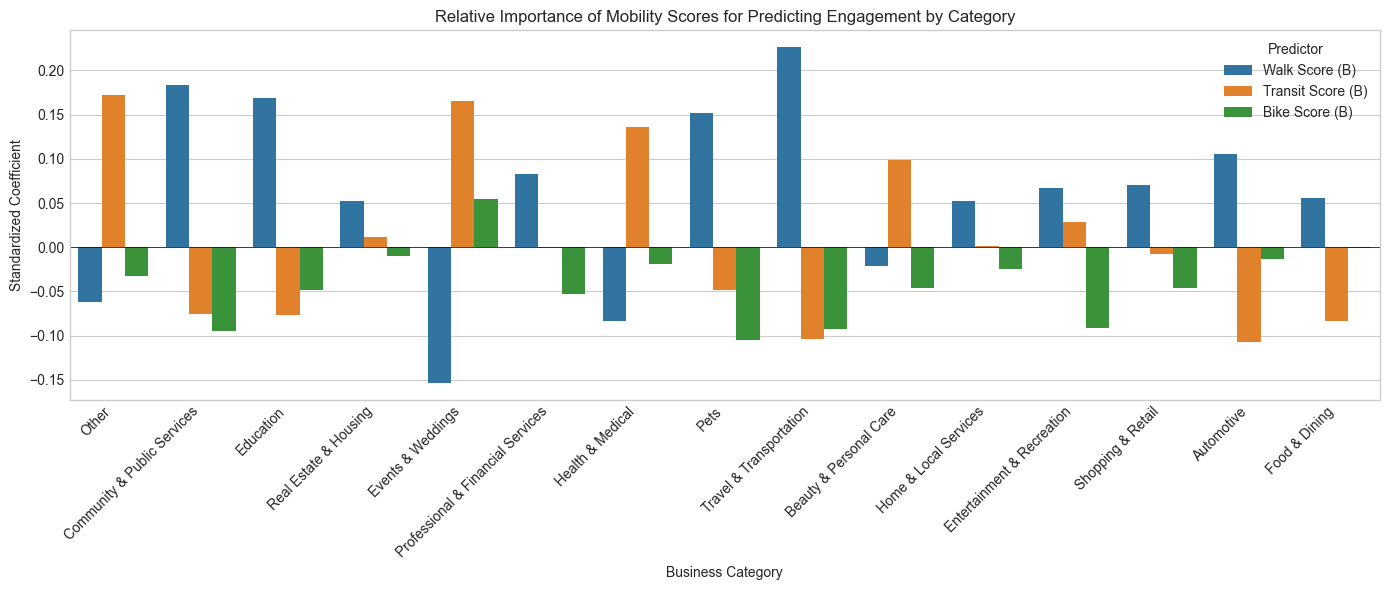

In [246]:
# Visualize regression coefficients
reg_plot_df = reg_df.melt(
    id_vars=['Category', 'R-squared', 'n'],
    value_vars=['Walk Score (B)', 'Transit Score (B)', 'Bike Score (B)'],
    var_name='Predictor',
    value_name='Coefficient'
)

plt.figure(figsize=(14, 6))
sns.barplot(data=reg_plot_df, x='Category', y='Coefficient', hue='Predictor')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Business Category')
plt.ylabel('Standardized Coefficient')
plt.title('Relative Importance of Mobility Scores for Predicting Engagement by Category')
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.legend(title='Predictor', loc='upper right')
plt.tight_layout()
plt.show()

## 4.4 3D Visualization

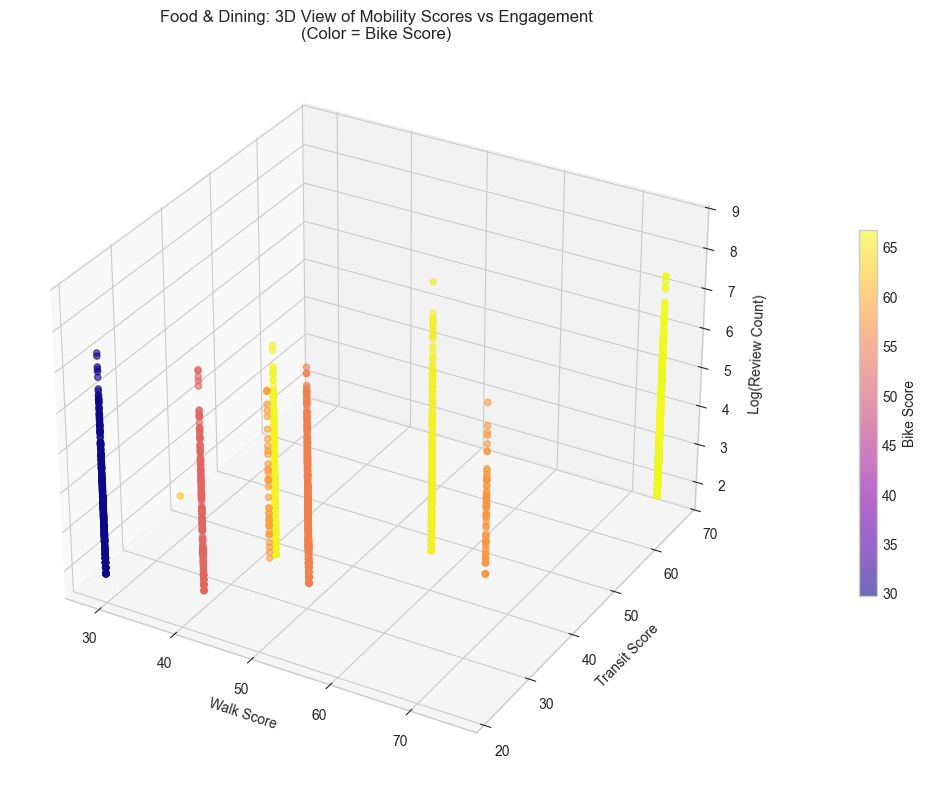

In [247]:
# 3D scatter: Walk x Transit x Review Count, colored by Bike Score
food_data = multivar_df[multivar_df['category'] == 'Food & Dining'].sample(
    n=min(2000, len(multivar_df[multivar_df['category'] == 'Food & Dining'])), random_state=42)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    food_data['Walk Score'],
    food_data['Transit Score'],
    food_data['log_review_count'],
    c=food_data['Bike Score'],
    cmap='plasma',
    alpha=0.6,
    s=20
)

ax.set_xlabel('Walk Score')
ax.set_ylabel('Transit Score')
ax.set_zlabel('Log(Review Count)')
ax.set_title('Food & Dining: 3D View of Mobility Scores vs Engagement\n(Color = Bike Score)')
fig.colorbar(scatter, ax=ax, label='Bike Score', shrink=0.5, pad=0.1)
plt.tight_layout()
plt.show()

/var/folders/l_/50s_462d2p18z6_x65mc6x5r0000gn/T/ipykernel_48839/1725942670.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


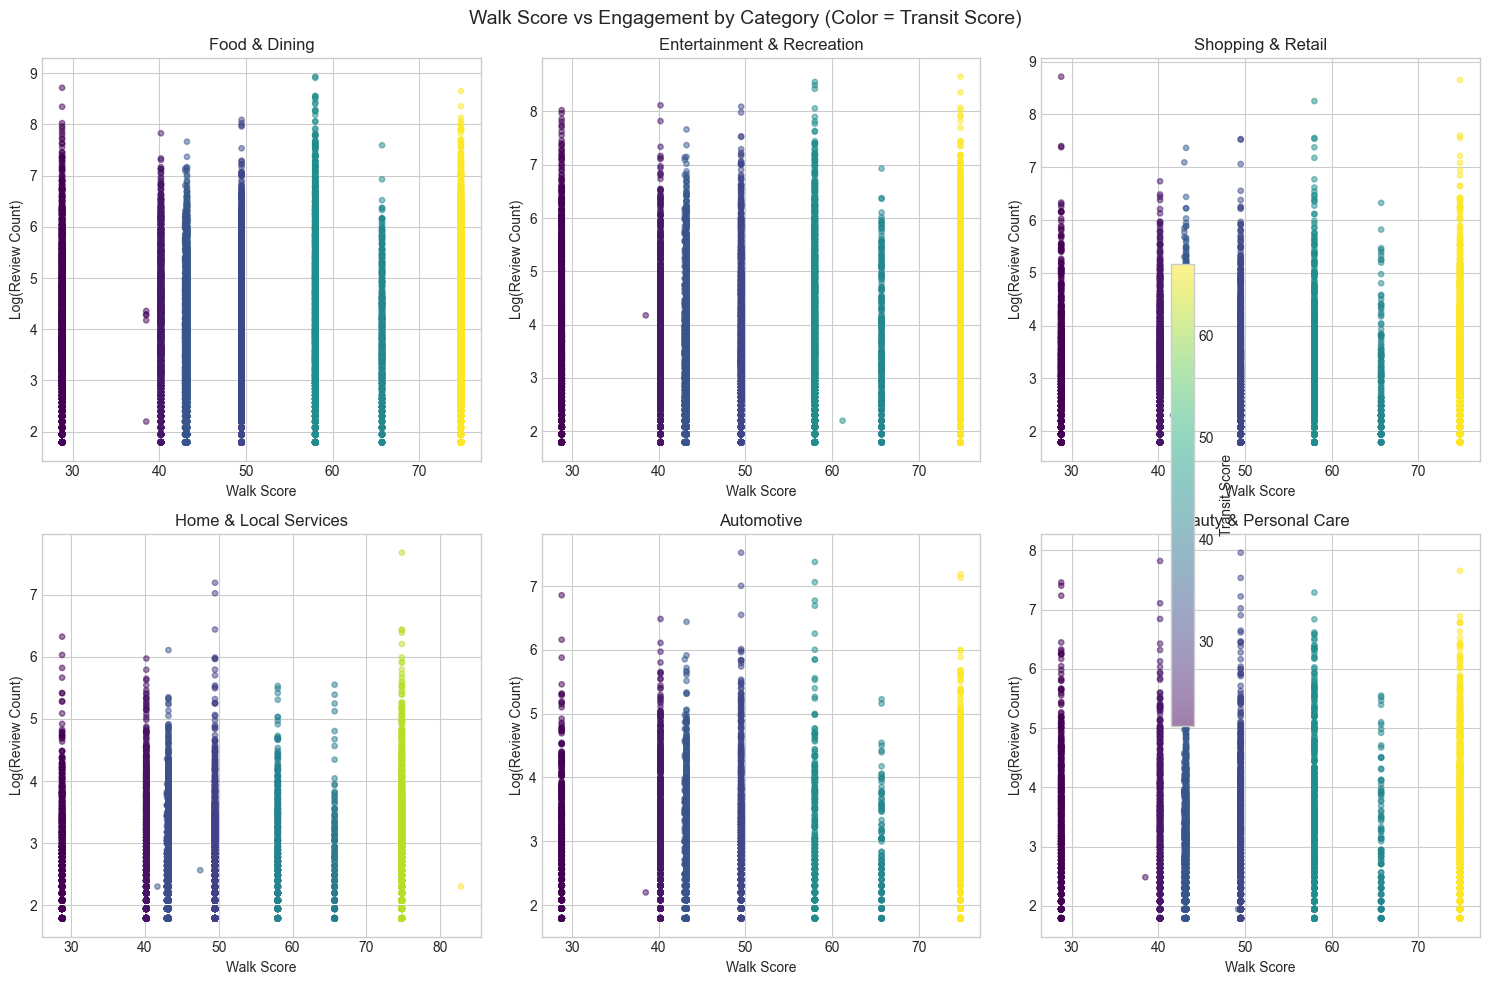

In [248]:
# Faceted scatter plots by category
top_categories = multivar_df['category'].value_counts().head(6).index.tolist()
plot_df = multivar_df[multivar_df['category'].isin(top_categories)]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, category in enumerate(top_categories):
    cat_data = plot_df[plot_df['category'] == category]
    ax = axes[idx]
    scatter = ax.scatter(
        cat_data['Walk Score'], 
        cat_data['log_review_count'],
        c=cat_data['Transit Score'],
        cmap='viridis',
        alpha=0.5,
        s=15
    )
    ax.set_xlabel('Walk Score')
    ax.set_ylabel('Log(Review Count)')
    ax.set_title(f'{category}')

plt.suptitle('Walk Score vs Engagement by Category (Color = Transit Score)', fontsize=14)
fig.colorbar(scatter, ax=axes, label='Transit Score', shrink=0.6)
plt.tight_layout()
plt.show()

## 4.5 Summary of Findings

In [249]:
print("="*60)
print("ANALYSIS SUMMARY")
print("="*60)

print("\n1. INFERENTIAL STATISTICS:")
print(f"   - ANOVA: Significant difference in Travel Score across categories (p < 0.05)")
print(f"   - Chi-Square: Business type distribution differs by transit level (p < 0.05)")
print(f"   - Regression: Mobility scores have weak but significant effect on engagement")

print("\n2. GRAPHICAL ANALYSIS:")
print("   - Review count is heavily right-skewed")
print("   - Food & Dining is the dominant category")
print("   - Mobility scores are highly correlated with each other")

print("\n3. COMPARATIVE ANALYSIS:")
print("   - High-transit cities have more businesses and higher engagement")
print("   - Food & Dining dominates in high-transit areas")
print("   - Automotive businesses are more common in low-transit areas")

print("\n4. MULTIVARIATE ANALYSIS:")
print("   - Walk Score tends to be the strongest predictor of engagement")
print("   - Effect sizes are small but statistically significant")
print("   - The relationship varies by business category")

ANALYSIS SUMMARY

1. INFERENTIAL STATISTICS:
   - ANOVA: Significant difference in Travel Score across categories (p < 0.05)
   - Chi-Square: Business type distribution differs by transit level (p < 0.05)
   - Regression: Mobility scores have weak but significant effect on engagement

2. GRAPHICAL ANALYSIS:
   - Review count is heavily right-skewed
   - Food & Dining is the dominant category
   - Mobility scores are highly correlated with each other

3. COMPARATIVE ANALYSIS:
   - High-transit cities have more businesses and higher engagement
   - Food & Dining dominates in high-transit areas
   - Automotive businesses are more common in low-transit areas

4. MULTIVARIATE ANALYSIS:
   - Walk Score tends to be the strongest predictor of engagement
   - Effect sizes are small but statistically significant
   - The relationship varies by business category
